Professions significant at p < 0.05 for all years:
- Lawyers
- Pharmacists
- Rehabilitation counselors


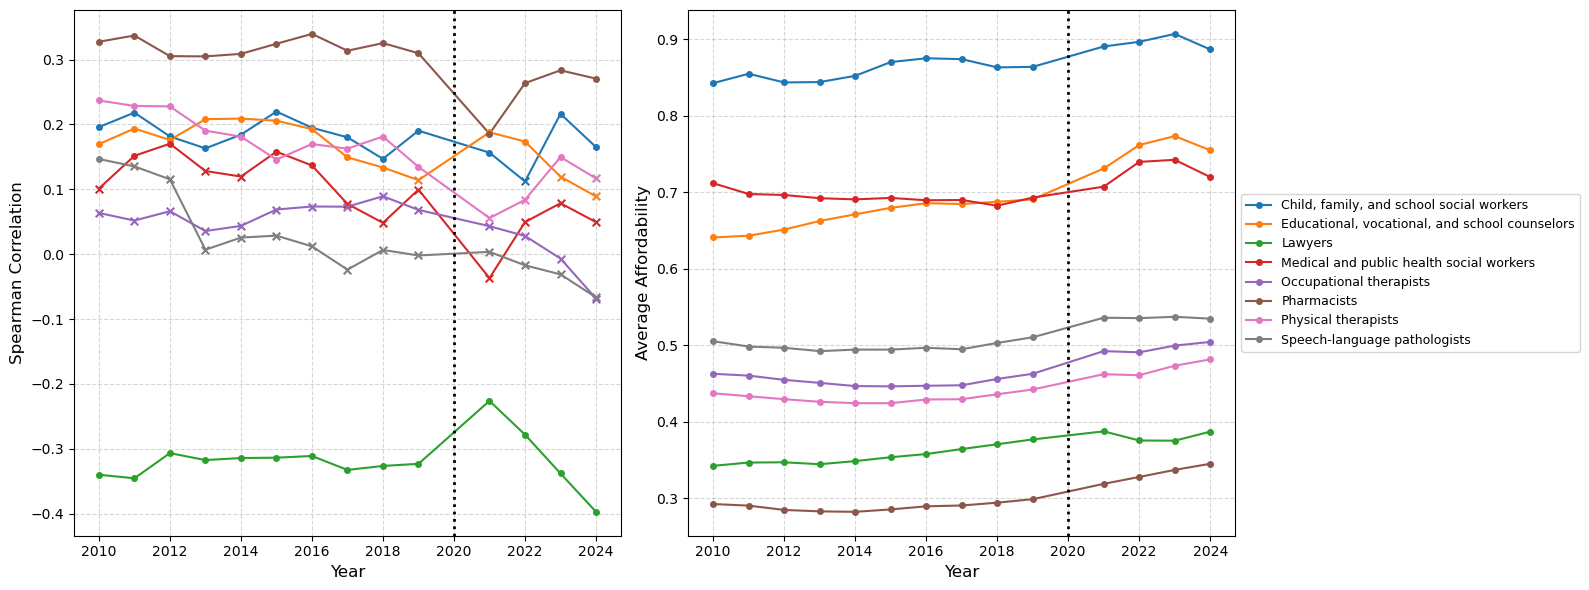

In [7]:
import pandas as pd
import geopandas as gpd
import os
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import getpass
import sys
from pathlib import Path
user = getpass.getuser()
PROJECT_ROOT = Path(f"/Users/{user}/Final_Lawyer_Git July10")
scripts_directory = PROJECT_ROOT / 'Scripts' / 'Helpers'

# Convert the Path object to a string and append it to sys.path
if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))
from Helpers import *

# Load data
# FIPS
fips_path = PROJECT_ROOT/"Data/Geography/FIPS/US states FIPS.csv"   # FIPS path
df_fips = pd.read_csv(fips_path)  # Load FIPS
df_fips["FIPS Code"] = df_fips["FIPS Code"].astype(str).str.zfill(2)  # Ensure string, add 0 to single digits

# MSAs
msa_shapefile_path = PROJECT_ROOT/"Data/Geography/CBSA_shapefile_2025/tl_2025_us_cbsa.shp"   # Shapefile path
gdf_msa = gpd.read_file(msa_shapefile_path)  # Load MSA shapefile

gdf_msa = gdf_msa[gdf_msa["LSAD"] == 'M1'].reset_index(drop=True)  # Remove micro
gdf_msa['State_Abbr'] = gdf_msa['NAME'].str[-2:]  # Get state abbreviations
gdf_msa = gdf_msa[gdf_msa['State_Abbr'].isin(df_fips['Postal Abbr.'])].copy()  # Filter only US states
valid_geoid = gdf_msa["GEOID"].astype(str).tolist()  # GEOID list

# Population
pop_path = PROJECT_ROOT/"Data/Population Data/MSA Population" # Population data Path
population_data = []  # Data structure

for year in list(range(2010, 2020)) + list(range(2021, 2025)):
    file_name = f"ACSDT1Y{year}.B01003-Data.csv"  # Dataset name
    full_path = os.path.join(pop_path, file_name)  # Create path

    df = pd.read_csv(full_path)  # Load data

    df = df[['GEO_ID', 'NAME', 'B01003_001E']].copy()  # Take relevant columns
    df.rename(columns={'GEO_ID': 'AREA', 'NAME': 'MSA', 'B01003_001E': 'Population'}, inplace=True)  # Rename columns

    df = df.iloc[1:].reset_index(drop=True)  # Remove first row

    df['AREA'] = df['AREA'].str[-5:]  # Get GEOID
    df["AREA"] = df["AREA"].astype(str)  # GEOID as string
    df["year"] = year  # Store year

    df = df[df["AREA"].isin(valid_geoid)]  # Take only MSAs from the list

    population_data.append(df)  # Add to list

df_population = pd.concat(population_data, ignore_index=True)
df_population['year'] = df_population['year'].astype(int)

# Lawyers wages
base_path = PROJECT_ROOT/"Data/Processed Data/Filtered Tables"   # Data path
msa_data = []  # Data structure

for year in range(2010, 2025):
    file_name = f"MSA_{year}_Filtered_Extended_Professions.xlsx"  # Dataset name
    full_path = os.path.join(base_path, file_name)  # Create path

    df = pd.read_excel(full_path)  # Load data

    df = df[['AREA', 'AREA_TITLE', 'OCC_TITLE', 'TOT_EMP', 'H_MEAN', 'A_MEAN', 'H_MEDIAN',
             'A_MEDIAN']].copy()  # Take relevant columns

    df["AREA"] = df["AREA"].astype(str)  # GEOID as string
    df["year"] = year  # Store year

    df = df[df["AREA"].isin(valid_geoid)]  # Take only MSAs

    msa_data.append(df)  # Add to list

# Build the dataset
all_data = pd.concat(msa_data, ignore_index=True)  # Create a single table
all_data.replace("*", pd.NA, inplace=True)  # Convert "*" to NaN
all_data["H_MEAN"] = pd.to_numeric(all_data["H_MEAN"], errors='coerce')  # To numeric
all_data["A_MEAN"] = pd.to_numeric(all_data["A_MEAN"], errors='coerce')  # To numeric
all_data["H_MEDIAN"] = pd.to_numeric(all_data["H_MEDIAN"], errors='coerce')  # To numeric
all_data["A_MEDIAN"] = pd.to_numeric(all_data["A_MEDIAN"], errors='coerce')  # To numeric
all_data["TOT_EMP"] = pd.to_numeric(all_data["TOT_EMP"], errors='coerce')  # To numeric
all_data.dropna(subset=["H_MEAN", "A_MEAN", 'H_MEDIAN', 'A_MEDIAN', "TOT_EMP"],
                inplace=True)  # Drop rows with missing values
all_data.sort_values(["AREA", "year"], inplace=True)  # Sort
all_data.reset_index(drop=True, inplace=True)  # Reset indexing

# Add population
all_data = all_data.merge(df_population[['AREA', 'year', 'Population']], on=['AREA', 'year'],
                          how='left')  # Add population
all_data['Population'] = pd.to_numeric(all_data['Population'], errors='coerce')  # Set population values numerical

# Calculate affordability ratio
all_data = all_data.dropna(subset=["Population"])  # Remove nan


# Filtering professions
def process_balanced_panel(df_filter):
    # Separate All Occupations to use as baseline
    df_baseline = df_filter[df_filter["OCC_TITLE"] == "All Occupations"].copy()
    df_baseline = df_baseline.rename(columns={"A_MEDIAN": "A_MEDIAN_All", "H_MEDIAN": "H_MEDIAN_All"})

    professions = [p for p in df_filter["OCC_TITLE"].unique() if p != "All Occupations"]
    num_years = df_filter["year"].nunique()

    results_list = []

    for profession in professions:
        df_prof = df_filter[df_filter["OCC_TITLE"] == profession].copy()

        # Keep only MSA-Year pairs where both the profession and the baseline exist
        merged = df_prof.merge(df_baseline[['AREA', 'year', 'A_MEDIAN_All', 'H_MEDIAN_All']], on=['AREA', 'year'],
                               how='inner')

        # Keep only MSAs that exist in ALL available years for this specific profession
        years_per_area = merged.groupby("AREA")["year"].nunique()
        valid_areas = years_per_area[years_per_area == num_years].index
        merged = merged[merged["AREA"].isin(valid_areas)]

        if not merged.empty:
            merged["A_Affordability_Ratio"] = merged["A_MEDIAN_All"] / merged["A_MEDIAN"]
            merged["H_Affordability_Ratio"] = merged["H_MEDIAN_All"] / merged["H_MEDIAN"]
            results_list.append(merged)

    return pd.concat(results_list, ignore_index=True)


df_final_ratios = process_balanced_panel(all_data)

# Save 2024 lawyer affordability data for Supplementary Figure 7
lawyers_2024 = df_final_ratios[
    (df_final_ratios["year"] == 2024) &
    (df_final_ratios["OCC_TITLE"] == "Lawyers")
][[
    "Population",
    "A_Affordability_Ratio"
]].copy()

lawyers_2024.to_csv(
    PROJECT_ROOT / "Data/Processed Data/Affordability/Supplementary_Figure_7_Lawyers_data.csv",
    index=False
)

# Save 2024 pharmacist affordability data for Supplementary Figure 7
pharmacists_2024 = df_final_ratios[
    (df_final_ratios["year"] == 2024) &
    (df_final_ratios["OCC_TITLE"] == "Pharmacists")
][[
    "Population",
    "A_Affordability_Ratio"
]].copy()

pharmacists_2024.to_csv(
    PROJECT_ROOT / "Data/Processed Data/Affordability/Supplementary_Figure_7_Pharmacists_data.csv",
    index=False
)
# Population-weighted average affordability
def weighted_avg(g):
    data = {'A_Afford_Weighted': (g['A_Affordability_Ratio'] * g['Population']).sum() / g['Population'].sum(),
            'H_Afford_Weighted': (g['H_Affordability_Ratio'] * g['Population']).sum() / g['Population'].sum()}
    return pd.Series(data)


df_weighted_trends = df_final_ratios.groupby(['year', 'OCC_TITLE']).apply(weighted_avg, include_groups=False).reset_index()
df_weighted_trends.to_csv(PROJECT_ROOT/"Data/Processed Data/Affordability/Annual_Average_Affordability_All.csv", index=False)   # Save data

# Spearman correlations
spearman_results = []
for (year, occ), group in df_final_ratios.groupby(['year', 'OCC_TITLE']):
    num_msas = group['AREA'].nunique()  # Count number of cities with specific profession data
    if len(group) > 5:
        rho, pval = spearmanr(group['Population'], group['A_Affordability_Ratio'])  # Spearman
        spearman_results.append({
            'year': year,
            'OCC_TITLE': occ,
            'Spearman_rho': rho,
            'p_Value': pval,
            'MSA_Count': num_msas}) # Store data

df_spearman_trends = pd.DataFrame(spearman_results)

# Spearman significance
alpha = 0.05
significant_profs = df_spearman_trends.groupby('OCC_TITLE').filter(lambda x: (x['p_Value'] < alpha).all())  # Find significant results
final_list = significant_profs['OCC_TITLE'].unique()   # Get unique list
print(f"Professions significant at p < {alpha} for all years:")
for prof in final_list: # Print professions
    print(f"- {prof}")

# Plotting
expected_years = set(range(2010, 2025)) - {2020}
num_expected = len(expected_years)

cont_spearman = df_spearman_trends.groupby('OCC_TITLE')['year'].nunique()
cont_weighted = df_weighted_trends.groupby('OCC_TITLE')['year'].nunique()

full_cont_profs = cont_spearman[(cont_spearman == num_expected) & (cont_weighted.reindex(cont_spearman.index) == num_expected)].index.tolist()  # Professions with data

# Filter professions by sample size
areas_per_prof = df_final_ratios.groupby("OCC_TITLE")["AREA"].nunique() # MSAs per profession
min_cities = 150    # Required sample size
profs_with_large_sample = areas_per_prof[areas_per_prof > min_cities].index.tolist()    # MSAs with large enough sample
full_cont_profs = [p for p in full_cont_profs if p in profs_with_large_sample]  # Keep only large enough samples

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for prof in full_cont_profs:
    spearman_sub = df_spearman_trends[df_spearman_trends['OCC_TITLE'] == prof].sort_values('year')  # Spearman data
    weighted_sub = df_weighted_trends[df_weighted_trends['OCC_TITLE'] == prof].sort_values('year')  # Affordability data

    # Separate significant and insignificant data
    sig_mask = spearman_sub['p_Value'] < alpha
    insig_mask = spearman_sub['p_Value'] >= alpha

    sig_points = spearman_sub[sig_mask] # Significant Spearman
    insig_points = spearman_sub[insig_mask] # Insignificant Spearman

    # Plot lines for all years
    line, = ax1.plot(spearman_sub['year'], spearman_sub['Spearman_rho'], label=prof)
    ax2.plot(weighted_sub['year'], weighted_sub['A_Afford_Weighted'], marker='o', markersize=4, label=prof)

    # Plot points for significant Spearman
    ax1.scatter(sig_points['year'], sig_points['Spearman_rho'],
                color=line.get_color(), marker='o', s=16, zorder=3)

    # Plot 'x' for insignificant Spearman
    ax1.scatter(insig_points['year'], insig_points['Spearman_rho'],
                color=line.get_color(), marker='x', s=30, zorder=3)

ax1.set_ylabel('Spearman Correlation', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)
ax1.axvline(x=2020, color='black', linestyle=':', linewidth=2)
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax2.set_ylabel('Average Affordability', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.axvline(x=2020, color='black', linestyle=':', linewidth=2)
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig(PROJECT_ROOT/"Figures/Figure 4/Figure_4_V1.pdf", dpi=300, bbox_inches='tight', transparent=True)  # Save
plt.show()

# Save the data
df_spearman_final = df_spearman_trends.rename(columns={
    'year': 'Year',
    'OCC_TITLE': 'Profession',
    'Spearman_rho': 'Spearman Rho',
    'p_value': 'P_Value',
    'MSA_Count': 'Number of MSAs'}) # Rename columns
df_spearman_final.to_csv(PROJECT_ROOT/"Data/Processed Data/Affordability/Annual_Affordability_Spearman_All.csv", index=False)   # Save data
